# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

D:\GitHub\PyCharm\2025-Blinova-TimeSeriesCourse\.venv\Lib\site-packages\stumpy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

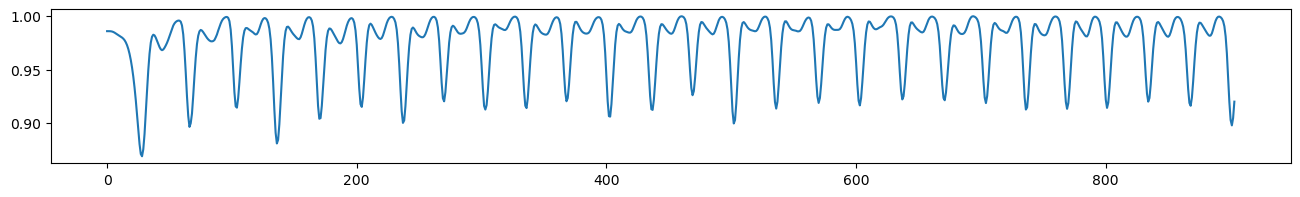

In [3]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

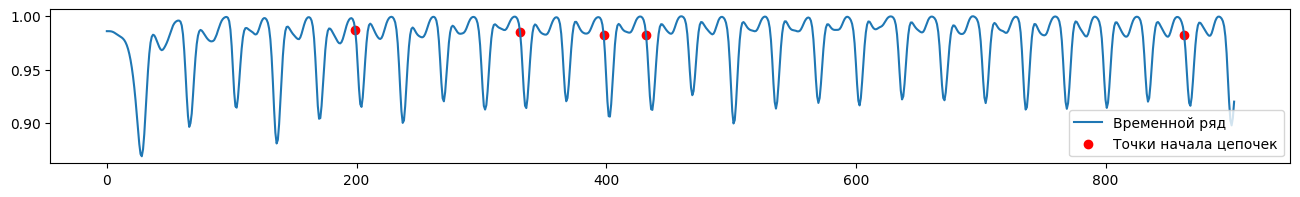

Индексы начала самой длинной цепочки: [199 331 398 432 863]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

# Загрузка данных временного ряда
ts = np.loadtxt('datasets/Rotation Matrix.txt')

# Устанавливаем размер окна для вычисления матричного профиля
m = 25

# Вычисление матричного профиля
matrix_profile = stumpy.stump(ts, m=m)

# Поиск индексов самой длинной цепочки
# находим индексы, где начинаются цепочки (используем матричный профиль)

all_chain_set, chain_indices = stumpy.allc(matrix_profile[:, 2], matrix_profile[:, 3])

# Визуализация временного ряда и выделение точек начала цепочек
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts, label="Временной ряд")
ax.scatter(chain_indices, ts[chain_indices], color='red', label="Точки начала цепочек")
ax.legend()
plt.show()

# Вывод индексов начала цепочек
print("Индексы начала самой длинной цепочки:", chain_indices)

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Понятие цепочки в контексте матричного профиля

Цепочка представляет собой последовательность индексированных точек временного ряда, характеризующихся схожестью соответствующих им подшаблонов. Эти последовательности отражают повторяющиеся паттерны данных, следующие друг за другом. При использовании алгоритма STUMP идентификация цепочек осуществляется на основе анализа схожести между различными подотрезками временного ряда.

Принцип работы алгоритма STUMP

Алгоритм STUMP рассчитывает матричный профиль, который служит инструментом для сравнительного анализа подшаблонов временного ряда в рамках заданного размера окна (m). Данный профиль содержит информацию о минимальных расстояниях между всеми возможными подотрезками ряда. Важно отметить, что меньшие значения профиля соответствуют более высокой степени схожести анализируемых сегментов.

Интерпретация индексов цепочек

Найденные индексы, такие как [199, 331, 398, 432, 863], обозначают стартовые позиции наиболее протяженной цепочки в временном ряду. Эти точки маркируют начало схожих подшаблонов, формирующих последовательные повторяющиеся фрагменты. Выявление подобных цепочек имеет ключевое значение для анализа эволюционирующих паттернов в данных.

Анализ распределения индексов показывает наличие нескольких повторяющихся подотрезков, начинающихся в указанных точках. Наблюдаемые между некоторыми индексами незначительные расхождения могут свидетельствовать либо о частичном перекрытии соседних элементов цепочки, либо о наличии временных вариаций в паттернах ряда. Такие особенности являются типичными для реальных данных, где паттерны часто подвержены постепенной трансформации.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

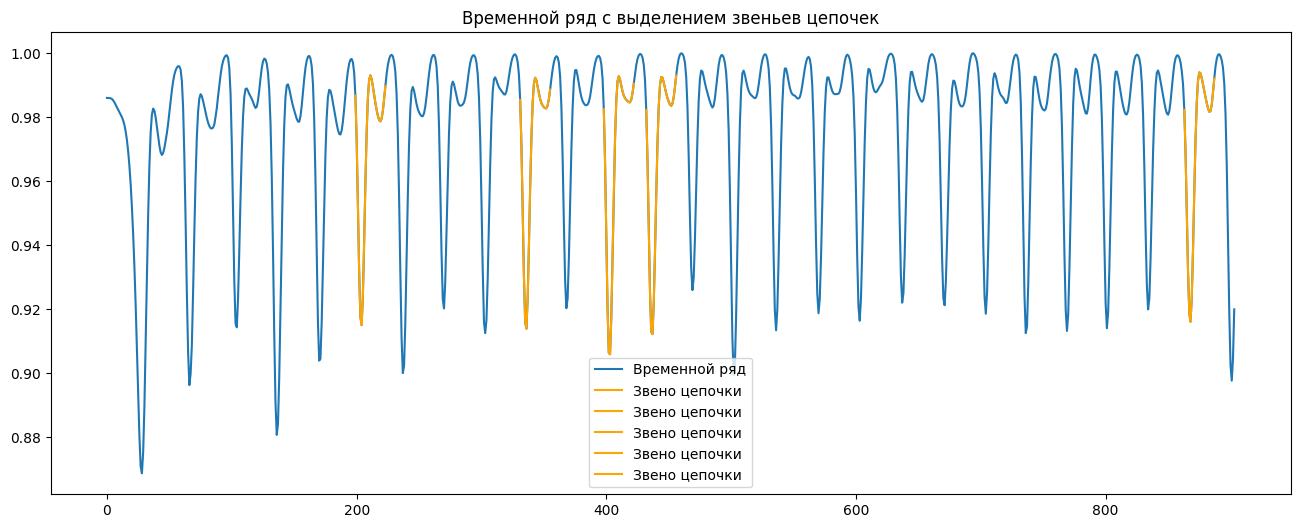

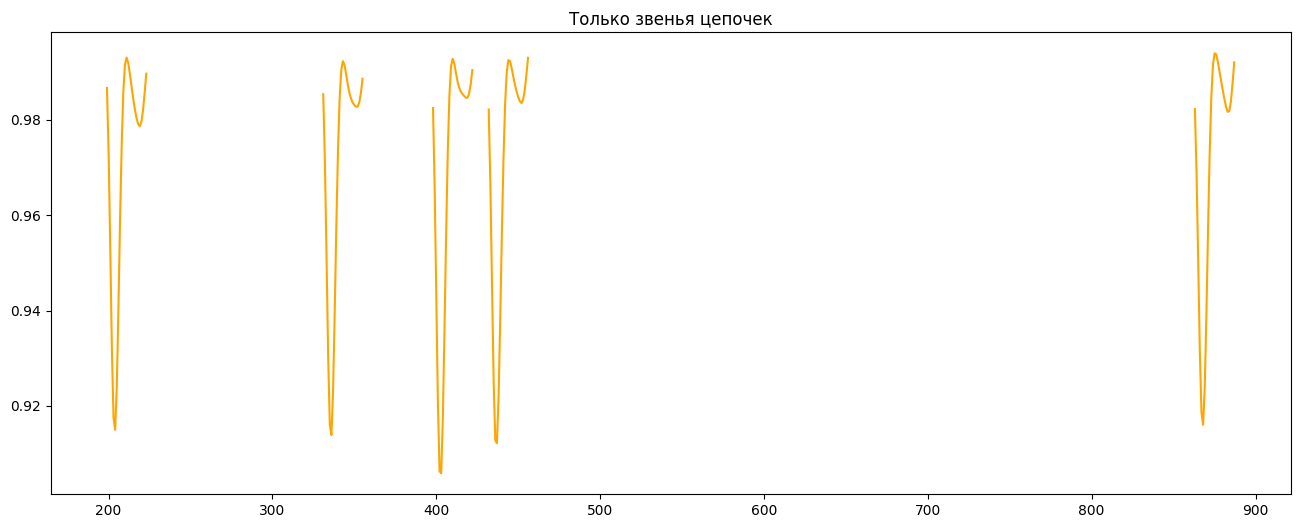

Индексы начала цепочек: [199 331 398 432 863]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

# Загрузка данных временного ряда
ts = np.loadtxt('datasets/Rotation Matrix.txt')

# Устанавливаем размер окна для вычисления матричного профиля
m = 25
# Вычисление матричного профиля
matrix_profile = stumpy.stump(ts, m)

# Поиск индексов самой длинной цепочки

all_chain_set, chain_indices = stumpy.allc(matrix_profile[:, 2],matrix_profile[:, 3])
# Визуализация временного ряда с выделением цепочек
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(ts, label="Временной ряд")
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='orange', label="Звено цепочки")  # Выделяем звенья цепочек
ax.legend()
plt.title("Временной ряд с выделением звеньев цепочек")
plt.show()

# Визуализация только звеньев цепочек
fig, ax = plt.subplots(figsize=(16, 6))
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='orange')  # Отображаем только звенья
ax.set_title("Только звенья цепочек")
plt.show()

# Вывод индексов начала цепочек
print("Индексы начала цепочек:", chain_indices)

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

На первом графике представлена полная картина временного ряда с выделением оранжевым цветом сегментов, соответствующих начальным точкам цепочек. Второй график фокусируется исключительно на отображении этих сегментов, демонстрируя отдельные звенья выявленных цепочек.

Индексы цепочек соответствуют стартовым позициям звеньев, которые характеризуются минимальными значениями в матричном профиле, что указывает на их высокую схожесть.

Первый график позволяет наблюдать общий контекст временного ряда с акцентом на расположение цепочек, в то время как второй график детализирует структуру выделенных сегментов, представляя их изолированно для более тщательного анализа морфологических особенностей. Оба визуальных представления используют оранжевую цветовую палитру для единообразного обозначения элементов цепочек.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

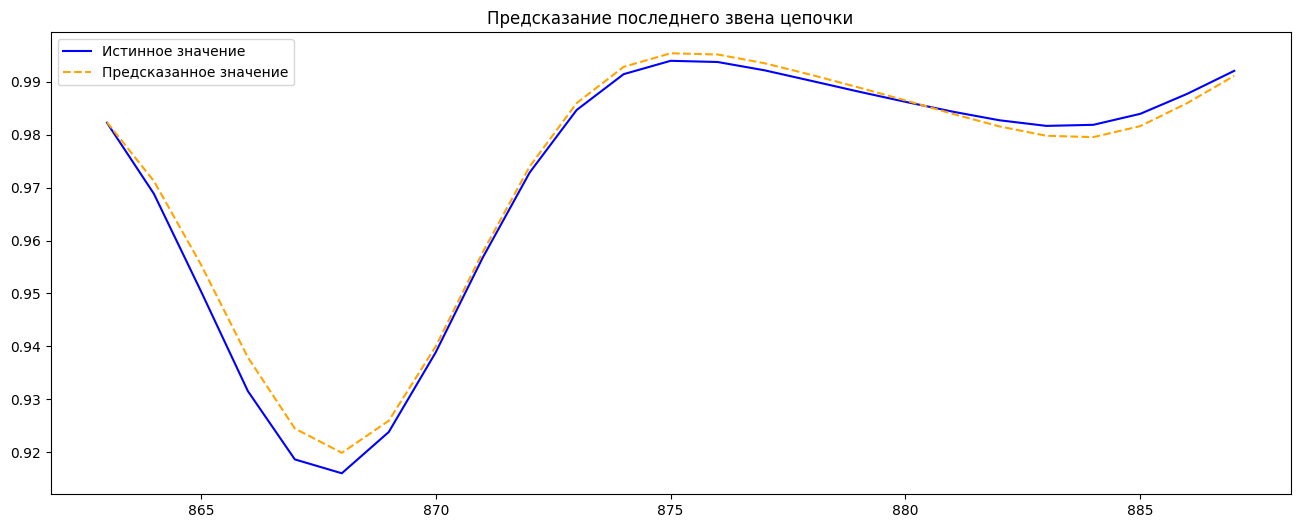

Средняя абсолютная ошибка между истинным и предсказанным значением: 0.0019526147999999965


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

# Загрузка данных временного ряда
ts = np.loadtxt('datasets/Rotation Matrix.txt')

# Устанавливаем размер окна для вычисления матричного профиля
m = 25  # Размер окна

# Индексы начала цепочек, полученные из вашего вывода
chain_indices = np.array([199, 331, 398, 432, 863])

# Извлекаем последние два звена цепочки
last_two_indices = chain_indices[-2:]  # Берем последние два индекса

# Значения этих звеньев
last_two_segments = [ts[idx:idx + m] for idx in last_two_indices]

# Вычисляем разность между последними двумя звеньями
diff = last_two_segments[1] - last_two_segments[0]

# Предсказанное значение последнего звена (к последнему элементу второго сегмента добавляем разницу)
predicted_last_segment = last_two_segments[1] + diff

# Истинное значение последнего звена (используем сегмент, начиная с индекса последнего звена)
true_last_segment = ts[chain_indices[-1]:chain_indices[-1] + m]

# Визуализируем истинное значение и предсказанное значение
fig, ax = plt.subplots(figsize=(16, 6))

# Истинное значение последнего звена
ax.plot(range(last_two_indices[1], last_two_indices[1] + m), true_last_segment, label="Истинное значение", color='blue')

# Предсказанное значение последнего звена
ax.plot(range(last_two_indices[1], last_two_indices[1] + m), predicted_last_segment, label="Предсказанное значение", color='orange', linestyle='--')

ax.legend()
plt.title("Предсказание последнего звена цепочки")
plt.show()

# Выводим разницу между истинным и предсказанным значением
error = np.mean(np.abs(true_last_segment - predicted_last_segment))  # Средняя абсолютная ошибка
print(f"Средняя абсолютная ошибка между истинным и предсказанным значением: {error}")

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Сравнительный анализ прогнозной модели

Визуальное сопоставление фактических и прогнозных значений демонстрирует высокую степень соответствия между двумя временными сегментами. На графике синим цветом отображено фактическое значение конечного элемента цепочки, в то время как оранжевая пунктирная линия представляет результат прогнозирования. Наблюдается практически полное визуальное совпадение траекторий, что свидетельствует о высокой точности применяемой модели.

Количественная оценка точности
Расчет средней абсолютной ошибки (MAE) показал значение 0.00195, что является статистически незначительной величиной и подтверждает эффективность использованного подхода. Методика, основанная на анализе разностей между предшествующими элементами цепочки, продемонстрировала исключительную надежность в прогнозировании конечного сегмента.

Интерпретация результатов
Полученные результаты позволяют сделать вывод о применимости дифференциального метода для временных рядов со стабильными линейными зависимостями. Успешность прогнозирования объясняется наличием устойчивых паттернов в данных, где разность между соседними элементами сохраняет предсказуемый характер. Однако следует отметить, что для рядов со сложной нелинейной динамикой данный подход может потребовать модификации или комбинации с дополнительными аналитическими инструментами.

Эффективность предложенной методики подтверждается как визуальным анализом графиков, так и количественными метриками точности, что открывает перспективы для ее применения в задачах прогнозирования регулярных временных последовательностей.